# About the data

### This dataset was produced by Marianne Bertrand of the University of Chicago and Sendhil Mullainathan of MIT as part of a study on racial discrimation in the job market. They sent 5,000 fictitious resumes to 1,300 job postings based in Boston and Chicago over the course of two years and measured how many received a response. Resumes were randomly assigned to two categories based on whether the name of the applicant was racially identified with African-Americans (e.g., "Aisha") or with Whites (e.g., "Laurie"). 

### There are 62 resume features total, which include not only the typical job application features like: education level, working experience, technical skill, but also features would be available in public data, such as: honors, military experiences. 


### The paper can be found here: https://www.aeaweb.org/articles?id=10.1257/0002828042002561

---

# Data Analysis

## Import data

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn import cross_validation
from sklearn.cross_validation import cross_val_score

from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from statsmodels.stats.weightstats import ztest
from scipy.stats import chi2_contingency

/anaconda3/lib/python3.6/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


In [2]:
data = pd.io.stata.read_stata('data/lakisha_aer.dta')

In [3]:
data.head()

,id,ad,education,ofjobs,yearsexp,honors,volunteer,military,empholes,occupspecific,...,compreq,orgreq,manuf,transcom,bankreal,trade,busservice,othservice,missind,ownership
0,b,1,4,2,6,0,0,0,1,17,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,
1,b,1,3,3,6,0,1,1,0,316,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,
2,b,1,4,1,6,0,0,0,0,19,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,
3,b,1,3,4,6,0,1,0,1,313,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,
4,b,1,3,3,22,0,0,0,0,313,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Nonprofit


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4870 entries, 0 to 4869
Data columns (total 65 columns):
id                    4870 non-null object
ad                    4870 non-null object
education             4870 non-null int8
ofjobs                4870 non-null int8
yearsexp              4870 non-null int8
honors                4870 non-null int8
volunteer             4870 non-null int8
military              4870 non-null int8
empholes              4870 non-null int8
occupspecific         4870 non-null int16
occupbroad            4870 non-null int8
workinschool          4870 non-null int8
email                 4870 non-null int8
computerskills        4870 non-null int8
specialskills         4870 non-null int8
firstname             4870 non-null object
sex                   4870 non-null object
race                  4870 non-null object
h                     4870 non-null float32
l                     4870 non-null float32
call                  4870 non-null float32
city        

## Feature engineering

In [3]:
# Replace "race" column with number
mask_w = data.race == "w"
mask_b = data.race == "b"
data.loc[mask_w, 'race'] = 0
data.loc[mask_b, 'race'] = 1
data.race = data.race.astype(float)

In [4]:
# Replace "sex" column with number
mask_f = data.sex == "f"
mask_m = data.sex == "m"
data.loc[mask_f, 'sex'] = 0
data.loc[mask_m, 'sex'] = 1
data.sex = data.sex.astype(float)

In [5]:
# Drop all the non-numeric columns
data1 = data.drop(['id','ad','firstname','city',
                 'kind','expminreq','schoolreq','ownership'],axis=1)

In [6]:
# Replace the NaN value with "0"
data2 = data1.fillna(0)

## Cross Validation

In [7]:
# select predicted feature as y, prediction feature as x
data_x = data2.loc[:, data2.columns != 'call']
data_y = data2.call

X = data_x.as_matrix()
Y = data_y.as_matrix()

In [8]:
# split the data into training part and testing part
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=3)

/Applications/anaconda/lib/python3.5/site-packages/sklearn/model_selection/_split.py:2026: FutureWarning: From version 0.21, test_size will always complement train_size unless both are specified.
  FutureWarning)


## Train the model

In [9]:
# Decision Tree Model
decision_tree_classifier = DecisionTreeClassifier()
decision_tree_classifier.fit(X_train, Y_train,)
decision_tree_classifier.score(X_test, Y_test)
#decision_tree_classifier.score(X_train, Y_train) == 1

0.86789869952087606

In [10]:
# SVM Model
svm_rbf = svm.SVC(kernel='rbf', gamma=500)
svm_rbf.fit(X_train,Y_train)
#svm_rbf.score(X_train,Y_train) == 1
svm_rbf.score(X_test, Y_test)

0.92470910335386725

In [11]:
# Random Forest
rdf = RandomForestClassifier(max_depth=5, n_estimators=30)
rdf.fit(X_train,Y_train)
rdf.score(X_test, Y_test)

0.92470910335386725

In [13]:
#Five Machine learning model here:

#svm_rbf = svm.SVC(kernel='rbf', gamma=500)
#decision_tree_classifier = DecisionTreeClassifier()
#rdf = RandomForestClassifier(max_depth=5, n_estimators=30)
#bagb = AdaBoostClassifier(DecisionTreeClassifier(max_depth=10), n_estimators=20)
#gradb = GradientBoostingClassifier(max_depth=5, n_estimators=30)

#cv_scores1 = cross_val_score(svm_rbf, X, Y, cv=10)
#cv_scores2 = cross_val_score(decision_tree_classifier, X, Y, cv=10)
#cv_scores3 = cross_val_score(rdf, X, Y, cv=10)
#cv_scores4 = cross_val_score(bagb, X, Y, cv=10)
#cv_scores5 = cross_val_score(gradb, X, Y, cv=10)

-----

# Data Discrimination Discussion

### I measured the racial discrimination both in the original data and model results, in order to see whether the original data is biased and whether the machine learning approach has changed it or not.

### For discrimination measurement, I tried to use two different tests: Z test and Chi-Square test to measure the independence  between the "race" and "resume acceptance". If they are not independent, the racial discrimination would be considered to exist. I found Chi-Square test is more appropriate than Z test here.

### For the machine learning approach, I used two machine learning algorithms(Decision Tree and KNN) here to see whether they will have different performances in data discrimination. I found they are all neutral even the training data is biased.

## Original Data Discrimination(Z test, Chi-Square test)

### Original data = training data + testing data

In [22]:
# Z test approach
ztest(data.call[data.race == 0],data.call[data.race == 1], alternative = 'two-sided')

(4.1147053567507346, 3.8767429116085706e-05)

In [21]:
# Chi-Square approach
chi2_contingency(pd.crosstab(data.race, data.call))

(16.449028584189371, 4.9975783899632552e-05, 1, array([[ 2239.,   196.],
        [ 2239.,   196.]]))

### Z test and Chi-Square test both concludes that  racial discrimination exists in original data.

### Training data and Testing data

In [38]:
# Create dataframe for training data
df3 = {'race': pd.Series(X_train[:,14]), 'call': Y_train}
df3 = pd.DataFrame(df3)
df3.call = df3.call.astype(int)
df3.race = df3.race.astype(int)

In [39]:
ztest(df3.call[df3.race == 0],df3.call[df3.race == 1],alternative = 'two-sided')

(3.4285696859851957, 0.00060677074099661755)

In [40]:
chi2_contingency(pd.crosstab(df3.race, df3.call))

(11.299646367328158,
 0.00077521854828049527,
 1,
 array([[ 1546.53036081,   139.46963919],
        [ 1580.46963919,   142.53036081]]))

### Both Z test and Chi-Square test think that there is racial discrimination in training data

In [41]:
# Create dataframe for testing data
df2 = {'race': pd.Series(X_test[:,14]), 'call': Y_test}
df2 = pd.DataFrame(df2)
df2.call = df2.call.astype(int)
df2.race = df2.race.astype(int)

In [42]:
ztest(df2.call[df2.race == 0],df2.call[df2.race == 1],alternative = 'two-sided')

(2.3050838513099619, 0.021161877727017536)

In [43]:
chi2_contingency(pd.crosstab(df2.race, df2.call))

(4.8544899466131266,
 0.027574265435771236,
 1,
 array([[ 692.60711841,   56.39288159],
        [ 658.39288159,   53.60711841]]))

### Both Z test and Chi-Square test think no racial discrimination in testing data

## KNN Discrimination Inspection(Z test, Chi-Square test)

In [24]:
# Train the KNN model
neigh = KNeighborsClassifier(n_neighbors=2)
neigh.fit(X_train, Y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=2, p=2,
           weights='uniform')

In [25]:
# KNN prediction data
dfK = {'race': pd.Series(X_test[:,14]), 'call': pd.Series(neigh.predict(X_test))}
dfK = pd.DataFrame(dfK)
dfK.call = dfK.call.astype(int)
dfK.race = dfK.race.astype(int)

In [27]:
ztest(dfK.call[dfK.race == 0],dfK.call[dfK.race == 1],alternative = 'two-sided')

(0.54236961422844687, 0.5875639077645709)

In [28]:
chi2_contingency(pd.crosstab(dfK.race, dfK.call))

(0.1042080380682802,
 0.74683709573366419,
 1,
 array([[ 738.23408624,   10.76591376],
        [ 701.76591376,   10.23408624]]))

### Both Z test and Chi-Square test think there is no racial discrimination in KNN's prediction results, which means the KNN is racial-biased in this case.

## Decision Tree's Discrimination Inspection(Z test and Chi-Square test)

In [30]:
# Predicted results
decision_tree_classifier = DecisionTreeClassifier()
decision_tree_classifier.fit(X_train, Y_train)
call = decision_tree_classifier.predict(X_test)

In [31]:
# Create dataframe for prediction data
df = {'race': pd.Series(X_test[:,14]), 'call': pd.Series(call)}
df = pd.DataFrame(df)
df.call = df.call.astype(int)
df.race = df.race.astype(int)

In [33]:
ztest(df.call[df.race == 0],df.call[df.race == 1],alternative = 'two-sided')

(-0.76096107903489818, 0.44668031471177683)

In [34]:
chi2_contingency(pd.crosstab(df.race, df.call))

(0.44937278348450321,
 0.50263296004983449,
 1,
 array([[ 680.81587953,   68.18412047],
        [ 647.18412047,   64.81587953]]))

### Both Z test and Chi-Square test think there is no racial discrimination in Decision Tree's prediction results, which means the Decision Tree is racial-biased in this case.

# Data Visualization

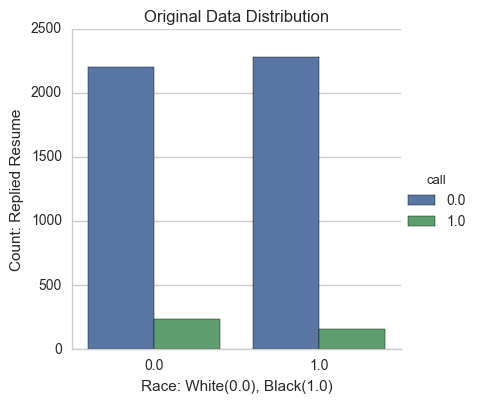

In [55]:
# Original data factor distribution
sns.factorplot(x="race", kind="count", hue="call", data=data)
plt.title('Original Data Distribution')
plt.xlabel('Race: White(0.0), Black(1.0)')
plt.ylabel('Count: Replied Resume')
#plt.savefig('output/original.png')

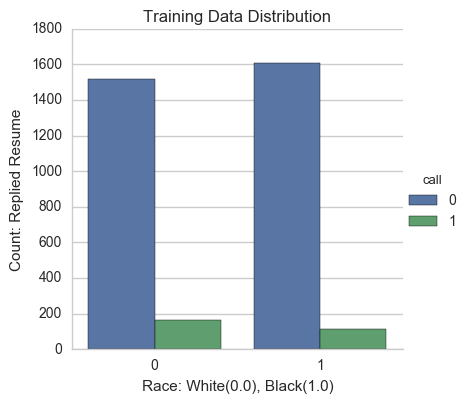

In [59]:
# Training data
sns.factorplot(x="race", kind="count", hue="call", data=df3)
plt.title('Training Data Distribution')
plt.xlabel('Race: White(0.0), Black(1.0)')
plt.ylabel('Count: Replied Resume')
#plt.savefig('output/traindata.png')

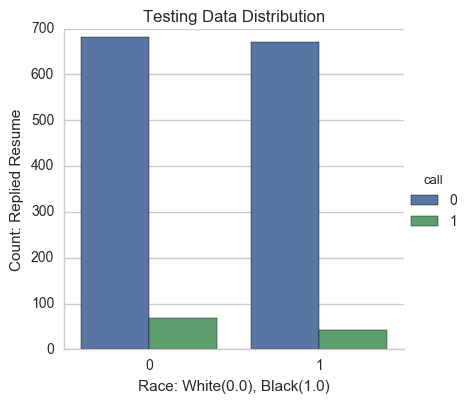

In [60]:
# Testing data
sns.factorplot(x="race", kind="count", hue="call", data=df2)
plt.title('Testing Data Distribution')
plt.xlabel('Race: White(0.0), Black(1.0)')
plt.ylabel('Count: Replied Resume')
#plt.savefig('output/testdata.png')

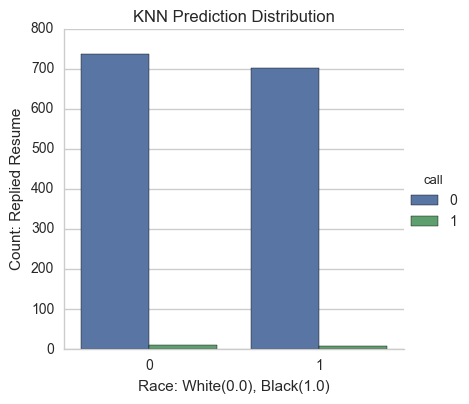

In [61]:
# KNN Prediction Results
sns.factorplot(x="race", kind="count", hue="call", data=dfK)
plt.title('KNN Prediction Distribution')
plt.xlabel('Race: White(0.0), Black(1.0)')
plt.ylabel('Count: Replied Resume')
plt.savefig('output/knndata.png')

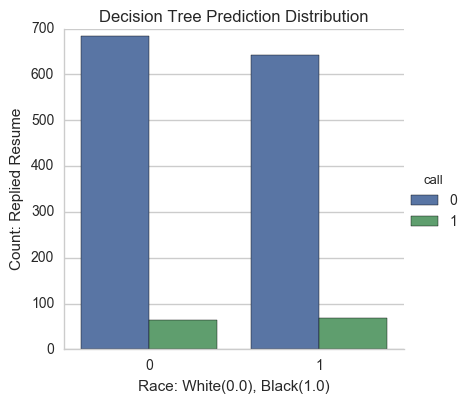

In [62]:
# Decision Tress Prediction Results
sns.factorplot(x="race", kind="count", hue="call", data=df)
plt.title('Decision Tree Prediction Distribution')
plt.xlabel('Race: White(0.0), Black(1.0)')
plt.ylabel('Count: Replied Resume')
#plt.savefig('output/dtdata.png')

### Surprised to notice it both from statistical test results and data visualization that: Decision Tree has better anti-discrimination statistical performance than KNN in this case.